# Ответить на вопросы
1. Продифференцировать задачу линейной регрессии в матрично-векторной форме


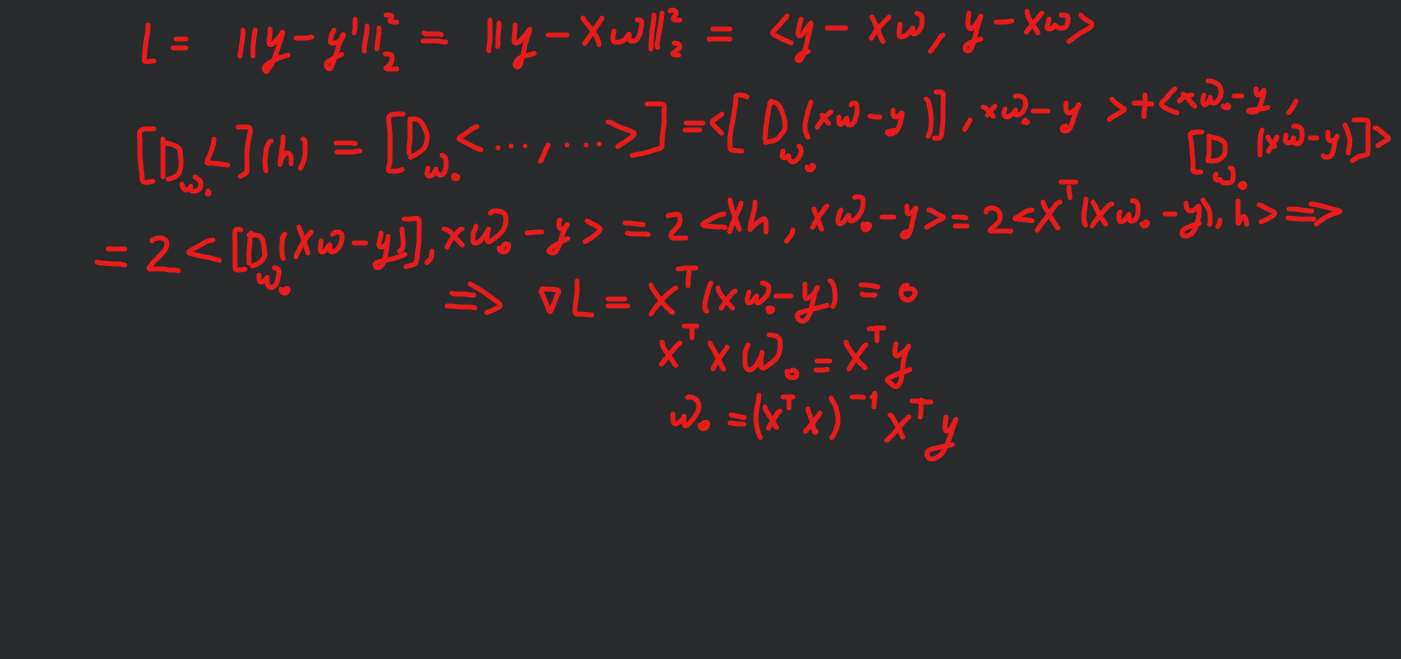

2. Что изменяется в решении при добавлении $L_1$- и $L_2$-регуляризации?

Добавляется регуляризационный член $λ||ω||_k^k$

Добавление регуляризационного члена накладывает на решение ограничения, в итоге решение получается не таким точным, но из-за снижения вычислительных проблем качество решения вырастет:

*   $L_2$: добавляется $λ|ω_i|^2$, в решении к $X^TX$ добавляется $\lambda I$, а к шагу градиента добавляется $2\alpha\lambda$, $\alpha$ - шаг градиента
*   $L_1$: добавляется $λ|ω_i|$, аналитического решения нет, т.к. модуль не дифференцируем, но к шагу градиента добавляется $\alpha\lambda sign(ω_i)$

$L_2$ наказывает больше за большие веса

3. Почему $L_1$ используется для отбора признаков?

$L_1$-регуляризация имеет свойство разрежения весов признаков, которые не влияют на таргет. Происходит это, потому что оптимум вектора весов лежит в точке касания линий уровня лосса и таргета. Линии уровня $L_1$-нормы имеют вид N-мерного октаэдра, а значит намного выше шанс, что оптимум будет лежать на его угле. Эти углы, как раз находятся в области, где признаки зануляются

4. Нелинейные зависимости учитываеются моделью, если создавать нелинейные признаки, по которым модель будет всё ещё линейна

Introduction — make all the preprocessing staff from the previous lesson

* Import libraries.
* Read Train and Test Parts.
* Preprocess "Interest Level" feature.

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

In [131]:
data = pd.read_json("/content/drive/MyDrive/ML/ML2/datasets/train.json")

<Axes: ylabel='price'>

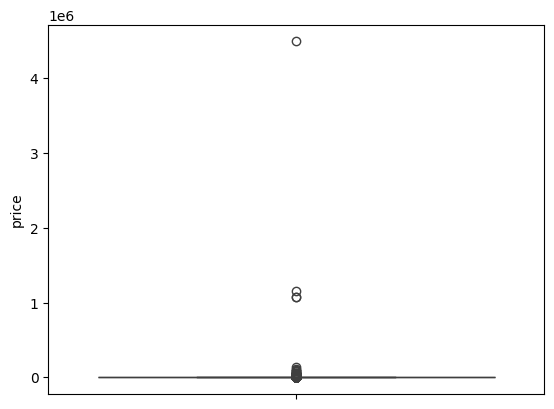

In [120]:
sns.boxplot(data['price'])

In [132]:
data = data[data['price'] < 1e6]

<Axes: ylabel='price'>

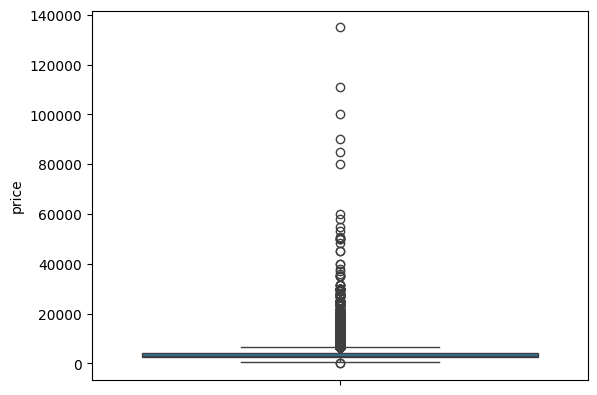

In [122]:
sns.boxplot(data['price'])

In [133]:
data['interest_level'] = data['interest_level'].map({'low': 0, 'medium': 1, 'high': 2})

обработаем колонку features

In [135]:
data['features'] = data['features'].map(
    lambda x: [f.replace(' ', '').replace('"', '').replace("'", '') for f in x]
)

feature_list = []
for i in data.iterrows():
  feature_list.extend(i[1]['features'])

print(len(set(feature_list)))

from collections import Counter
top20 = Counter(feature_list).most_common(20)
top20 = [x[0] for x in top20]

print(top20)

1546
['Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


In [136]:
for f in top20:
  data[f] = data['features'].apply(lambda x: int(f in x))

In [137]:
top20.extend(['bathrooms', 'bedrooms'])

In [138]:
X, y = data[top20], data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, random_state=21)

# 4 - Models implementation — Linear regression

Детерменированный SGD выдаёт и один и тот же результат при подачи одинаковых входов. Для этого зафиксируем семя рандом для перемешивания выборки, а веса будем инициализировать не случайно, а 0

In [141]:
import numpy as np

class MyLinearRegression:
  def __init__(self, lr=0.01, n_epochs=1000):
    self.w = None
    self.b = None
    self.lr = lr
    self.n_epochs = n_epochs

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    n_samples, n_features = X.shape

    self.w = np.zeros(n_features,)
    self.b = 0

    rng = np.random.default_rng(21)

    for epoch in range(self.n_epochs):
      indices = rng.permutation(n_samples)

      for i in indices:
        x_i = X[i]
        y_i = y[i]

        y_pred = x_i @ self.w + self.b
        err = y_i - y_pred
        self.w += self.lr * err * x_i
        self.b += self.lr * err

    return self

  def predict(self, X):
    return X @ self.w + self.b

$R^2$ - метрика, показывающая какую часть дисперсии данных модель объяснила

$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$

${SS_{\text{res}}}$ - сумма квадратов ошибок предсказаний

${SS_{\text{tot}}}$ - сумма квадратов отклонений данных от их среднего

In [142]:
def r_squared(y_true, y_pred):
  SS_res = np.sum((y_true - y_pred) ** 2)
  SS_tot = np.sum((y_true - np.mean(y_true)) ** 2)

  return 1 - SS_res / SS_tot

def MAE(y_true, y_pred):
  return np.mean(np.abs(y_true - y_pred))

def RMSE(y_true, y_pred):
  return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [143]:
mlr = MyLinearRegression(lr=0.01, n_epochs=1000)
mlr.fit(X_train, y_train)

In [144]:
y_pred_train_mlr = mlr.predict(X_train)
y_pred_test_mlr = mlr.predict(X_test)

mae_train_mlr = MAE(y_train, y_pred_train_mlr)
mae_test_mlr = MAE(y_test, y_pred_test_mlr)

rmse_train_mlr = RMSE(y_train, y_pred_train_mlr)
rmse_test_mlr = RMSE(y_test, y_pred_test_mlr)

r_squared_train_mlr = r_squared(y_train, y_pred_train_mlr)
r_squared_test_mlr = r_squared(y_test, y_pred_test_mlr)

print(mae_train_mlr)
print(mae_test_mlr)

print(rmse_train_mlr)
print(rmse_test_mlr)

print(r_squared_train_mlr)
print(r_squared_test_mlr)

973.6708305482537
967.5603635631662
1948.9489913497255
1858.2657438267809
0.42051267737138953
0.4290310446184331


In [139]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [145]:
y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr = lr.predict(X_test)

mae_train_lr = MAE(y_train, y_pred_train_lr)
mae_test_lr = MAE(y_test, y_pred_test_lr)

rmse_train_lr = RMSE(y_train, y_pred_train_lr)
rmse_test_lr = RMSE(y_test, y_pred_test_lr)

r_squared_train_lr = r_squared(y_train, y_pred_train_lr)
r_squared_test_lr = r_squared(y_test, y_pred_test_lr)

print(mae_train_lr)
print(mae_test_lr)

print(rmse_train_lr)
print(rmse_test_lr)

print(r_squared_train_lr)
print(r_squared_test_lr)

866.0327432316923
862.7745352942785
1906.9362158400493
1812.3877167134365
0.44522698587173926
0.45687590039594406


In [146]:
import numpy as np

class MyFullLinearRegression:
  def __init__(self, lr=0.01, n_epochs=1000):
    self.w = None
    self.b = None
    self.lr = lr
    self.n_epochs = n_epochs

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    n_samples, n_features = X.shape

    self.w = np.zeros(n_features,)
    self.b = 0

    for epoch in range(self.n_epochs):

      y_pred = X @ self.w + self.b
      err = y_pred - y
      self.w -= self.lr * (1 / n_samples) * (X.T @ err)
      self.b -= self.lr * np.mean(err)

    return self

  def predict(self, X):
    return X @ self.w + self.b

In [147]:
flr = MyFullLinearRegression()
flr.fit(X_train, y_train)

In [148]:
y_pred_train_flr = flr.predict(X_train)
y_pred_test_flr = flr.predict(X_test)

mae_train_flr = MAE(y_train, y_pred_train_flr)
mae_test_flr = MAE(y_test, y_pred_test_flr)

rmse_train_flr = RMSE(y_train, y_pred_train_flr)
rmse_test_flr = RMSE(y_test, y_pred_test_flr)

r_squared_train_flr = r_squared(y_train, y_pred_train_flr)
r_squared_test_flr = r_squared(y_test, y_pred_test_flr)

print(mae_train_flr)
print(mae_test_flr)

print(rmse_train_flr)
print(rmse_test_flr)

print(r_squared_train_flr)
print(r_squared_test_flr)

855.154440870405
848.4325006225195
1921.1435163607077
1825.1506114326253
0.4369297098903079
0.4491995707148261


In [149]:
import numpy as np

class MyRidge:
  def __init__(self, lr=0.01, n_epochs=1000, C=0.1):
    self.w = None
    self.b = None
    self.C = C
    self.lr = lr
    self.n_epochs = n_epochs

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    n_samples, n_features = X.shape

    self.w = np.zeros(n_features,)
    self.b = 0

    for epoch in range(self.n_epochs):

      y_pred = X @ self.w + self.b
      err = y_pred - y

      dw = (1 / n_samples) * (X.T @ err) + 2 * self.C * self.w
      db = np.mean(err)

      self.w -= self.lr * dw
      self.b -= self.lr * db


    return self

  def predict(self, X):
    return X @ self.w + self.b

In [150]:
mr = MyRidge()
mr.fit(X_train, y_train)

In [151]:
y_pred_train_mr = mr.predict(X_train)
y_pred_test_mr = mr.predict(X_test)

mae_train_mr = MAE(y_train, y_pred_train_mr)
mae_test_mr = MAE(y_test, y_pred_test_mr)

rmse_train_mr = RMSE(y_train, y_pred_train_mr)
rmse_test_mr = RMSE(y_test, y_pred_test_mr)

r_squared_train_mr = r_squared(y_train, y_pred_train_mr)
r_squared_test_mr = r_squared(y_test, y_pred_test_mr)

print(mae_train_mr)
print(mae_test_mr)

print(rmse_train_mr)
print(rmse_test_mr)

print(r_squared_train_mr)
print(r_squared_test_mr)

863.8682564103617
851.7118088237261
1996.1462244660256
1899.8693076187938
0.39210622343906365
0.4031787098833638


In [152]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

Ridge(alpha=0.1)

In [153]:
y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

mae_train = MAE(y_train, y_pred_train)
mae_test = MAE(y_test, y_pred_test)

rmse_train = RMSE(y_train, y_pred_train)
rmse_test = RMSE(y_test, y_pred_test)

r_squared_train = r_squared(y_train, y_pred_train)
r_squared_test = r_squared(y_test, y_pred_test)

print(mae_train)
print(mae_test)

print(rmse_train)
print(rmse_test)

print(r_squared_train)
print(r_squared_test)

866.029905306737
862.7714460855846
1906.9362159441362
1812.3875728558094
0.4452269858111766
0.4568759866165031


In [154]:
import numpy as np

class MyLasso:
  def __init__(self, lr=0.01, n_epochs=1000, C=0.1):
    self.w = None
    self.b = None
    self.C = C
    self.lr = lr
    self.n_epochs = n_epochs

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    n_samples, n_features = X.shape

    self.w = np.zeros(n_features,)
    self.b = 0

    for epoch in range(self.n_epochs):

      y_pred = X @ self.w + self.b
      err = y_pred - y

      dw = (1 / n_samples) * (X.T @ err) + self.C * np.sign(self.w)
      db = np.mean(err)

      self.w -= self.lr * dw
      self.b -= self.lr * db


    return self

  def predict(self, X):
    return X @ self.w + self.b

In [155]:
lasso = MyLasso()
lasso.fit(X_train, y_train)

In [156]:
y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

mae_train = MAE(y_train, y_pred_train)
mae_test = MAE(y_test, y_pred_test)

rmse_train = RMSE(y_train, y_pred_train)
rmse_test = RMSE(y_test, y_pred_test)

r_squared_train = r_squared(y_train, y_pred_train)
r_squared_test = r_squared(y_test, y_pred_test)

print(mae_train)
print(mae_test)

print(rmse_train)
print(rmse_test)

print(r_squared_train)
print(r_squared_test)

855.1347174088663
848.4106211728549
1921.181809343338
1825.1786072330658
0.4369072629928815
0.4491826732411952


In [157]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [158]:
y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

mae_train = MAE(y_train, y_pred_train)
mae_test = MAE(y_test, y_pred_test)

rmse_train = RMSE(y_train, y_pred_train)
rmse_test = RMSE(y_test, y_pred_test)

r_squared_train = r_squared(y_train, y_pred_train)
r_squared_test = r_squared(y_test, y_pred_test)

print(mae_train)
print(mae_test)

print(rmse_train)
print(rmse_test)

print(r_squared_train)
print(r_squared_test)

865.8620526460369
862.5828036588659
1906.937285038078
1812.35076163097
0.44522636376138824
0.45689804906874365


In [179]:
import numpy as np

class MyElasticNet:
  def __init__(self, lr=0.01, n_epochs=1000, C1=0.1, C2=0.1):
    self.w = None
    self.b = None
    self.C1 = C1
    self.C2 = C2
    self.lr = lr
    self.n_epochs = n_epochs

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    n_samples, n_features = X.shape

    self.w = np.zeros(n_features,)
    self.b = 0

    for epoch in range(self.n_epochs):

      y_pred = X @ self.w + self.b
      err = y_pred - y

      dw = (1 / n_samples) * (X.T @ err) + 2 * self.C1 * self.w + self.C2 * np.sign(self.w)
      db = np.mean(err)

      self.w -= self.lr * dw
      self.b -= self.lr * db


    return self

  def predict(self, X):
    return X @ self.w + self.b

In [160]:
elastic = MyElasticNet()
elastic.fit(X_train, y_train)

In [161]:
y_pred_train = elastic.predict(X_train)
y_pred_test = elastic.predict(X_test)

mae_train = MAE(y_train, y_pred_train)
mae_test = MAE(y_test, y_pred_test)

rmse_train = RMSE(y_train, y_pred_train)
rmse_test = RMSE(y_test, y_pred_test)

r_squared_train = r_squared(y_train, y_pred_train)
r_squared_test = r_squared(y_test, y_pred_test)

print(mae_train)
print(mae_test)

print(rmse_train)
print(rmse_test)

print(r_squared_train)
print(r_squared_test)

851.9267782193211
844.8204219450989
1927.4368299256455
1831.5219398045692
0.43323463774193127
0.4453473344613488


In [162]:
elastic = ElasticNet(alpha=0.2, l1_ratio=0.5)
elastic.fit(X_train, y_train)

ElasticNet(alpha=0.2)

In [163]:
y_pred_train = elastic.predict(X_train)
y_pred_test = elastic.predict(X_test)

mae_train = MAE(y_train, y_pred_train)
mae_test = MAE(y_test, y_pred_test)

rmse_train = RMSE(y_train, y_pred_train)
rmse_test = RMSE(y_test, y_pred_test)

r_squared_train = r_squared(y_train, y_pred_train)
r_squared_test = r_squared(y_test, y_pred_test)

print(mae_train)
print(mae_test)

print(rmse_train)
print(rmse_test)

print(r_squared_train)
print(r_squared_test)

847.4463212666703
839.3737667831894
1948.7315691605245
1853.1372749206603
0.42064196384838837
0.43217823269311484


# Нормализация признаков
Нужна:
1. если признаки имеют разные масштабы, то градиент вектора весов будет иметь координаты разных масштабов. Чтобы уменьшить ошибку предсказания, на каждой итерации мы движемся с одинаковой скоростью для всех координат и можем перелетать оптимум и не сойтись. Тот же Adam сглаживает, но не решает эту проблему
2. В случае регуляризации штраф, накладываемый на функцию потерь, будет штрафовать больший признак меньше (т.к. у него будут меньше веса), а маленький больше, даже если вклад признаков одинаковый

Не нужна:
1. в случае уже нормализованный признаков
2. Для деревьев не важно, т.к. они используют решающие правила


MinMaxScaler = $\frac{x - x_{min}}{x_{max} - x_{min}}$

In [170]:
import numpy as np

class MyMinMaxScaler:
  def __init__(self):
    self.min = None
    self.max = None

  def fit(self, X):
    X = np.array(X)
    self.min = X.min(axis=0)
    self.max = X.max(axis=0)

  def transform(self, X):
    X = np.array(X)
    denom = (self.max - self.min)
    denom[denom == 0] = 1
    return (X - self.min) / denom

  def fit_transform(self, X):
    self.fit(X)
    return self.transform(X)

In [171]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled_skl = scaler.fit_transform(X_train)

scaler = MyMinMaxScaler()
X_scaled = scaler.fit_transform(X_train)

np.allclose(X_scaled_skl, X_scaled)

True

In [172]:
import numpy as np

class MyStandardScaler:
  def __init__(self):
    self.mean = None
    self.std = None

  def fit(self, X):
    X = np.array(X)
    self.mean = X.mean(axis=0)
    self.std = X.std(axis=0)

  def transform(self, X):
    X = np.array(X)
    denom = self.std
    denom[denom == 0] = 1
    return (X - self.mean) / denom

  def fit_transform(self, X):
    self.fit(X)
    return self.transform(X)

In [173]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_skl = scaler.fit_transform(X_train)

scaler = MyStandardScaler()
X_scaled = scaler.fit_transform(X_train)

np.allclose(X_scaled_skl, X_scaled)

True

In [174]:
scaler_m = MinMaxScaler()
scaler_s = StandardScaler()

X_train_m = scaler_m.fit_transform(X_train)
X_test_m = scaler_m.transform(X_test)

X_train_s = scaler_s.fit_transform(X_train)
X_test_s = scaler_s.transform(X_test)

In [189]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet

models = {
    "My LR": LinearRegression(),
    "My Ridge": Ridge(),
    "My Lasso": Lasso(),
    "My ElasticNet": ElasticNet(alpha=0.01, l1_ratio=1e-5)
}

results = []

for name, model in models.items():
    model.fit(X_train_m, y_train)

    y_train_pred = model.predict(X_train_m)
    y_test_pred = model.predict(X_test_m)

    results.append({
        "model": name + " (MinMax)",
        "MAE train": MAE(y_train, y_train_pred),
        "MAE test": MAE(y_test, y_test_pred),
        "RMSE train": RMSE(y_train, y_train_pred),
        "RMSE test": RMSE(y_test, y_test_pred),
        "R2 train": r_squared(y_train, y_train_pred),
        "R2 test": r_squared(y_test, y_test_pred),
    })

pd.DataFrame(results)

,model,MAE train,MAE test,RMSE train,RMSE test,R2 train,R2 test
0,My LR (MinMax),866.032743,862.774535,1906.936216,1812.387717,0.445227,0.456876
1,My Ridge (MinMax),864.695310,861.353080,1907.002962,1812.488003,0.445188,0.456816
2,My Lasso (MinMax),862.801153,859.244285,1907.139377,1812.218252,0.445109,0.456977
3,My ElasticNet (MinMax),942.218065,928.324429,2113.460784,2018.119965,0.318554,0.326573


In [191]:
models = {
    "LR": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}

results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)

    y_train_pred = model.predict(X_train_s)
    y_test_pred = model.predict(X_test_s)

    results.append({
        "model": name + " (Standard)",
        "MAE train": MAE(y_train, y_train_pred),
        "MAE test": MAE(y_test, y_test_pred),
        "RMSE train": RMSE(y_train, y_train_pred),
        "RMSE test": RMSE(y_test, y_test_pred),
        "R2 train": r_squared(y_train, y_train_pred),
        "R2 test": r_squared(y_test, y_test_pred),
    })

pd.DataFrame(results)

,model,MAE train,MAE test,RMSE train,RMSE test,R2 train,R2 test
0,LR (Standard),866.032743,862.774535,1906.936216,1812.387717,0.445227,0.456876
1,Ridge (Standard),866.027255,862.768787,1906.936216,1812.387697,0.445227,0.456876
2,Lasso (Standard),865.420443,862.143960,1906.952105,1812.310167,0.445218,0.456922
3,ElasticNet (Standard),854.762081,847.423654,1960.198146,1865.035408,0.413804,0.424863


Теперь самописные модели

In [192]:
models = {
    "LR": MyFullLinearRegression(),
    "Ridge": MyRidge(),
    "Lasso": MyLasso(),
    "ElasticNet": MyElasticNet()
}

results = []

for name, model in models.items():
    model.fit(X_train_m, y_train)

    y_train_pred = model.predict(X_train_m)
    y_test_pred = model.predict(X_test_m)

    results.append({
        "model": name + " (MinMax)",
        "MAE train": MAE(y_train, y_train_pred),
        "MAE test": MAE(y_test, y_test_pred),
        "RMSE train": RMSE(y_train, y_train_pred),
        "RMSE test": RMSE(y_test, y_test_pred),
        "R2 train": r_squared(y_train, y_train_pred),
        "R2 test": r_squared(y_test, y_test_pred),
    })

pd.DataFrame(results)

,model,MAE train,MAE test,RMSE train,RMSE test,R2 train,R2 test
0,LR (MinMax),1096.265458,1076.740674,2305.984837,2210.281823,0.188748,0.192222
1,Ridge (MinMax),1171.823022,1149.563240,2394.669067,2297.056425,0.125149,0.127551
2,Lasso (MinMax),1096.302376,1076.769099,2306.058105,2210.344953,0.188696,0.192176
3,ElasticNet (MinMax),1171.875633,1149.614720,2394.733677,2297.116615,0.125102,0.127505


In [193]:
models = {
    "My LR": MyFullLinearRegression(),
    "My Ridge": MyRidge(),
    "My Lasso": MyLasso(),
    "My ElasticNet": MyElasticNet()
}

results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)

    y_train_pred = model.predict(X_train_s)
    y_test_pred = model.predict(X_test_s)

    results.append({
        "model": name + " (Standard)",
        "MAE train": MAE(y_train, y_train_pred),
        "MAE test": MAE(y_test, y_test_pred),
        "RMSE train": RMSE(y_train, y_train_pred),
        "RMSE test": RMSE(y_test, y_test_pred),
        "R2 train": r_squared(y_train, y_train_pred),
        "R2 test": r_squared(y_test, y_test_pred),
    })

pd.DataFrame(results)

,model,MAE train,MAE test,RMSE train,RMSE test,R2 train,R2 test
0,My LR (Standard),865.678798,862.332832,1907.018749,1812.448539,0.445179,0.456839
1,My Ridge (Standard),846.834237,841.747355,1920.530499,1825.794891,0.437289,0.448811
2,My Lasso (Standard),865.623450,862.275571,1907.020289,1812.441210,0.445178,0.456844
3,My ElasticNet (Standard),846.823951,841.738309,1920.551782,1825.809309,0.437277,0.448802


# Overfitting

In [213]:
from sklearn.preprocessing import PolynomialFeatures

X_small = data[['bathrooms', 'bedrooms', 'interest_level']]
poly = PolynomialFeatures(degree=10, include_bias=False)

X_poly = poly.fit_transform(X_small)
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly, y, shuffle=True, random_state=21)

In [214]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_poly_train)
X_scaled_test = scaler.transform(X_poly_test)

In [215]:
models = {
    "LR": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}

results = []

for name, model in models.items():
    model.fit(X_scaled_train, y_poly_train)

    y_train_pred = model.predict(X_scaled_train)
    y_test_pred = model.predict(X_scaled_test)

    results.append({
        "model": name + " (Standard)",
        "MAE train": MAE(y_poly_train, y_train_pred),
        "MAE test": MAE(y_poly_test, y_test_pred),
        "RMSE train": RMSE(y_poly_train, y_train_pred),
        "RMSE test": RMSE(y_poly_test, y_test_pred),
        "R2 train": r_squared(y_poly_train, y_train_pred),
        "R2 test": r_squared(y_poly_test, y_test_pred),
    })

pd.DataFrame(results)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.223e+09, tolerance: 2.426e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.928e+09, tolerance: 2.426e+07
  model = cd_fast.enet_coordinate_descent(


,model,MAE train,MAE test,RMSE train,RMSE test,R2 train,R2 test
0,LR (Standard),819.066559,7265.050469,1744.976562,569621.605211,0.535461,-53649.004188
1,Ridge (Standard),823.039516,827.394277,1763.862054,1847.821036,0.525351,0.435431
2,Lasso (Standard),826.802362,824.167685,1770.979392,1731.047898,0.521513,0.504533
3,ElasticNet (Standard),850.288852,841.267154,1817.605685,1726.241632,0.495986,0.507280


In [221]:
models = {
    "LR": MyFullLinearRegression(lr=0.05),
    "Ridge": MyRidge(lr=0.1),
    "Lasso": MyLasso(lr=0.1),
    "ElasticNet": MyElasticNet(lr=0.1)
}

results = []

for name, model in models.items():
    model.fit(X_scaled_train, y_poly_train)

    y_train_pred = model.predict(X_scaled_train)
    y_test_pred = model.predict(X_scaled_test)

    results.append({
        "model": name + " (Standard)",
        "MAE train": MAE(y_poly_train, y_train_pred),
        "MAE test": MAE(y_poly_test, y_test_pred),
        "RMSE train": RMSE(y_poly_train, y_train_pred),
        "RMSE test": RMSE(y_poly_test, y_test_pred),
        "R2 train": r_squared(y_poly_train, y_train_pred),
        "R2 test": r_squared(y_poly_test, y_test_pred),
    })

pd.DataFrame(results)

/tmp/ipykernel_8559/2780263122.py:22: RuntimeWarning: overflow encountered in matmul
  self.w -= self.lr * (1 / n_samples) * (X.T @ err)
/tmp/ipykernel_8559/2780263122.py:20: RuntimeWarning: invalid value encountered in matmul
  y_pred = X @ self.w + self.b
/tmp/ipykernel_8559/2780263122.py:22: RuntimeWarning: invalid value encountered in matmul
  self.w -= self.lr * (1 / n_samples) * (X.T @ err)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_8559/3038237686.py:24: RuntimeWarning: overflow encountered in matmul
  dw = (1 / n_samples) * (X.T @ err) + 2 * self.C * self.w
/tmp/ipykernel_8559/3038237686.py:21: RuntimeWarning: invalid value encountered in matmul
  y_pred = X @ self.w + self.b
/tmp/ipykernel_8559/3038237686.py:24: RuntimeWarning: invalid value encountered in matmul
  dw = (1 / n_samples) * (X.T @ err) + 2 * self.C * self.w
/tm

,model,MAE train,MAE test,RMSE train,RMSE test,R2 train,R2 test
0,LR (Standard),NaN,NaN,NaN,NaN,1.0,1.0
1,Ridge (Standard),NaN,NaN,NaN,NaN,1.0,1.0
2,Lasso (Standard),NaN,NaN,NaN,NaN,1.0,1.0
3,ElasticNet (Standard),NaN,NaN,NaN,NaN,1.0,1.0


при learning_rate = 0.01 результаты не отличались, при 0.1 NaN, вероятно, потому что настолько большие градиенты, что считать уже не получается

лучшая модель - с регуляризацией - ElasticNet.

In [229]:
y_mean = np.mean(y_train)

y_train_pred = np.full_like(y_train, y_mean)
y_test_pred = np.full_like(y_test, y_mean)


mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

rmse_train = RMSE(y_train, y_train_pred)
rmse_test = RMSE(y_test, y_test_pred)

r_squared_train = r_squared(y_train, y_train_pred)
r_squared_test = r_squared(y_test, y_test_pred)

print(mae_train)
print(mae_test)

print(rmse_train)
print(rmse_test)

print(r_squared_train)
print(r_squared_test)

1342.3737537488855
1319.7715814217395
2560.22719492697
2459.377356981188
-1.5347709103608054e-08
-0.00010867425630767258


In [231]:
y_meadian = np.median(y_train)

y_train_pred = np.full_like(y_train, y_meadian)
y_test_pred = np.full_like(y_test, y_meadian)


mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

rmse_train = RMSE(y_train, y_train_pred)
rmse_test = RMSE(y_test, y_test_pred)

r_squared_train = r_squared(y_train, y_train_pred)
r_squared_test = r_squared(y_test, y_test_pred)

print(mae_train)
print(mae_test)

print(rmse_train)
print(rmse_test)

print(r_squared_train)
print(r_squared_test)

1248.6003620545243
1226.4285482694333
2614.37179104749
2510.2299060369664
-0.0427439809343817
-0.0418947560230698


Лучшая модель: в теории должна быть ElasticNet, но похожу не те гиперпараметры. Везде выигрывала Lassoo, хотя модели шли впритирку

Со стабильностью похожая ситуация